In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

sys.path.insert(0, str(Path("..").resolve()))

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: mps
PyTorch: 2.12.0


### Full Preprocessing Pipeline on the RetailRocket Dataset

This step executes the complete preprocessing pipeline on the raw RetailRocket dataset, transforming the original interaction data into model-ready datasets.

The objective of this stage is to apply all previously defined data cleaning, filtering, transformation, and splitting procedures in a reproducible manner. By the end of the process, the raw data is converted into structured datasets that can be directly consumed by the recommendation model.

Key operations performed during preprocessing may include:

* Loading the raw interaction data.
* Applying user and item filtering rules.
* Removing noisy or low-information records.
* Encoding users and items into model-friendly identifiers.
* Validating dataset consistency and integrity.
* Generating metadata required for downstream pipeline stages.
* Creating train, validation, and test datasets.

The resulting splits are designed to support the full machine learning workflow:

* **Training set (`train`)** – Used to learn user and item representations.
* **Validation set (`val`)** – Used for model tuning, hyperparameter selection, and performance monitoring during development.
* **Test set (`test`)** – Reserved for final evaluation and unbiased performance assessment.

Executing the preprocessing pipeline on the full RetailRocket dataset ensures that all subsequent experiments are performed on a clean, consistent, and reproducible data foundation. This step represents the transition from exploratory analysis to model development, providing the final datasets required for training and evaluating the recommendation system.


In [2]:
RAW_PATH = Path("../data/raw")

print("Load Events.csv...")
events = pd.read_csv(RAW_PATH / "events.csv",
        usecols=["timestamp", "visitorid", "event", "itemid"],
        dtype={"visitor": "int32", "itemid": "int32"},)

print(f" {len(events):,} loadede events")

# Convert events into scores
EVENT_SCORES = {"view": 1.0, "addtocart": 2.0, "transaction": 3.0}
events["rating"] = events["event"].map(EVENT_SCORES)
events = events.rename(columns={"visitorid": "user_id", "itemid": "item_id"})

# Aggregate by user-item pair
print("Aggregating events by user-item pair...")
df = (
    events.groupby(["user_id", "item_id"], as_index=False).agg(rating=("rating", "max"), timestamp=("timestamp", "max"))
)
print(f"{len(df):,} unique pairs")

# Cold-start filter
print("Applying a cold-start filter (>= 10 iterations)...")
MIN_INTER = 5
for _ in range(5):
    uc = df["user_id"].value_counts()
    ic = df["item_id"].value_counts()
    df = df[
        df["user_id"].isin(uc[uc >= MIN_INTER].index) &
        df["item_id"].isin(ic[ic >= MIN_INTER].index)
    ]

print(f" {df['user_id'].nunique():,} users - {df['item_id'].nunique():,} items - {len(df):,} interactions")

# Normalize ratings
df["rating"] = (df["rating"] - df["rating"].min()) / (df["rating"].max() - df["rating"].min())

# Encode IDs
user_map = {uid: idx for idx, uid in enumerate(sorted(df["user_id"].unique()))}
item_map = {iid: idx for idx, iid in enumerate(sorted(df["item_id"].unique()))}
df["user_idx"] = df["user_id"].map(user_map).astype("int32")
df["item_idx"] = df["item_id"].map(item_map).astype("int32")

NUM_USERS = len(user_map)
NUM_ITEMS = len(item_map)
print(f"Encoded IDs: {NUM_USERS} users - {NUM_ITEMS} items")

# Time Split

df_sorted = df.sort_values("timestamp").reset_index(drop=True)
n = len(df_sorted)
val_start = int(n * 0.80)
test_start = int(n * 0.90)

train = df_sorted.iloc[:val_start].copy()
val   = df_sorted.iloc[val_start:test_start].copy()
test  = df_sorted.iloc[test_start:].copy()

print("Time split:")
print(f"train: {len(train):,} interactions")
print(f"val: {len(val):,} interactions")
print(f"test: {len(test):,} interactions")


Load Events.csv...
 2,756,101 loadede events
Aggregating events by user-item pair...
2,145,179 unique pairs
Applying a cold-start filter (>= 10 iterations)...
 23,620 users - 19,230 items - 255,398 interactions
Encoded IDs: 23620 users - 19230 items
Time split:
train: 204,318 interactions
val: 25,540 interactions
test: 25,540 interactions


### Building the MLP Recommendation Model

In this section, we construct the complete **Multi-Layer Perceptron (MLP)** architecture that will be used to learn user preferences and generate recommendations.

The goal is not only to define the model structure, but also to understand the role of each component and how the different layers work together to transform user and item information into meaningful predictions.

Key objectives of this step include:

* Defining the overall architecture of the recommendation model.
* Understanding how user and item embeddings are incorporated into the network.
* Examining the purpose of each layer and its contribution to the learning process.
* Understanding how the model captures complex interactions between users and items.
* Preparing the architecture for the training and evaluation stages.

The model receives encoded user and item identifiers as input, converts them into dense embedding vectors, and then processes these representations through a series of neural network layers. These layers learn increasingly complex patterns from historical interactions, enabling the model to estimate the likelihood that a user will engage with a particular item.

By analyzing the architecture layer by layer, we can better understand how information flows through the network, how predictions are generated, and why each design choice was made. This understanding is valuable both for model development and for communicating the technical rationale behind the recommendation system.

This cell represents the transition from data preparation to model construction, establishing the foundation that will be trained and evaluated in the subsequent stages of the project.


In [3]:
class EmbeddingMLP(nn.Module):
    """MLP with embeddings for recommendation."""

    def __init__(self, num_users, num_items, emb_dim, hidden_dims, dropout=0.2):
        super().__init__()

        # Embedding tables — one row per user/item
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        # Xavier initialization — helps prevent exploding/vanishing gradients
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

        # MLP: receives the concatenation of both embeddings (emb_dim * 2)
        layers = []
        in_dim = emb_dim * 2
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),   # linear transformation
                nn.BatchNorm1d(h),      # normalizes activations (more stable training)
                nn.ReLU(),              # non-linearity
                nn.Dropout(dropout),    # regularization (helps prevent overfitting)
            ]
            in_dim = h

        layers += [nn.Linear(in_dim, 1), nn.Sigmoid()]  # score in (0, 1)
        self.mlp = nn.Sequential(*layers)

    def forward(self, user_ids, item_ids):
        u = self.user_emb(user_ids)          # (B, emb_dim)
        i = self.item_emb(item_ids)          # (B, emb_dim)
        x = torch.cat([u, i], dim=-1)        # (B, emb_dim * 2)
        return self.mlp(x).squeeze(-1)       # (B,)


# Instantiate the model

EMBEDDING_DIM = 64
torch.manual_seed(42)
HIDDEN_DIMS = [128, 64, 32]
model = EmbeddingMLP(NUM_USERS, NUM_ITEMS, EMBEDDING_DIM, HIDDEN_DIMS).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model architecture:")
print(model)
print(f"\nTotal parameters : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print("\nData flow:")
print(f"  user    → emb({NUM_USERS}, {EMBEDDING_DIM}) → vector of size {EMBEDDING_DIM}")
print(f"  item    → emb({NUM_ITEMS}, {EMBEDDING_DIM}) → vector of size {EMBEDDING_DIM}")
print(f"  concat  → vector of size {EMBEDDING_DIM * 2}")
for h in HIDDEN_DIMS:
    print(f"  linear  → {h}")

Model architecture:
EmbeddingMLP(
  (user_emb): Embedding(23620, 64)
  (item_emb): Embedding(19230, 64)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total parameters : 2,769,729
Trainable parameters: 2,769,729

Data flow:
  user    → emb(23620, 64) → vector of size 64
  item    → emb(1

In [4]:
def make_interactions(df):
    """Converts a DataFrame into a dictionary for the model."""
    return {
        "user_ids": df["user_idx"].tolist(),
        "item_ids": df["item_idx"].tolist(),
        "ratings" : df["rating"].tolist(),
    }

def train_epoch(model, users, items, ratings, optimizer, criterion, batch_size=512):
    """Runs one training epoch and returns the average loss."""
    model.train()
    perm = torch.randperm(len(users))
    users, items, ratings = users[perm], items[perm], ratings[perm]

    total_loss, n_batches = 0.0, max(1, len(users) // batch_size)
    for b in range(n_batches):
        s, e = b * batch_size, (b + 1) * batch_size
        u = users[s:e].to(device)
        i = items[s:e].to(device)
        r = ratings[s:e].to(device)

        optimizer.zero_grad()
        loss = criterion(model(u, i), r)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / n_batches


# Prepare tensors
train_inter = make_interactions(train)
val_inter   = make_interactions(val)

users_t   = torch.tensor(train_inter["user_ids"], dtype=torch.long)
items_t   = torch.tensor(train_inter["item_ids"], dtype=torch.long)
ratings_t = torch.tensor(train_inter["ratings"],  dtype=torch.float)
users_v   = torch.tensor(val_inter["user_ids"],   dtype=torch.long)
items_v   = torch.tensor(val_inter["item_ids"],   dtype=torch.long)
ratings_v = torch.tensor(val_inter["ratings"],    dtype=torch.float)

# Training
torch.manual_seed(42)
model = EmbeddingMLP(NUM_USERS, NUM_ITEMS, EMBEDDING_DIM, HIDDEN_DIMS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion = nn.MSELoss()

NUM_EPOCHS = 50
PATIENCE   = 7

train_losses, val_losses = [], []
best_val_loss = float("inf")
patience_counter = 0
best_state = {}

print(f"Training for up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})...\n")

for epoch in range(NUM_EPOCHS):
    # Training
    train_loss = train_epoch(model, users_t, items_t, ratings_t, optimizer, criterion)

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(users_v.to(device), items_v.to(device))
        val_loss  = criterion(val_preds, ratings_v.to(device)).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:3d} | train={train_loss:.5f} | val={val_loss:.5f} | patience={patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\n  Early stopping at epoch {epoch + 1}!")
        break

# Restore best state
model.load_state_dict(best_state)
print(f"\n✓ Training completed! Best val_loss: {best_val_loss:.5f}")

Training for up to 50 epochs (early stopping patience=7)...

  Epoch   5 | train=0.02297 | val=0.05383 | patience=4/7

  Early stopping at epoch 8!

✓ Training completed! Best val_loss: 0.05078


In [5]:
def make_interactions(df):
    """Converts a DataFrame into a dictionary for the model."""
    return {
        "user_ids": df["user_idx"].tolist(),
        "item_ids": df["item_idx"].tolist(),
        "ratings" : df["rating"].tolist(),
    }

def train_epoch(model, users, items, ratings, optimizer, criterion, batch_size=512):
    """Runs one training epoch and returns the average loss."""
    model.train()
    perm = torch.randperm(len(users))
    users, items, ratings = users[perm], items[perm], ratings[perm]

    total_loss, n_batches = 0.0, max(1, len(users) // batch_size)
    for b in range(n_batches):
        s, e = b * batch_size, (b + 1) * batch_size
        u = users[s:e].to(device)
        i = items[s:e].to(device)
        r = ratings[s:e].to(device)

        optimizer.zero_grad()
        loss = criterion(model(u, i), r)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / n_batches


# Prepare tensors
train_inter = make_interactions(train)
val_inter   = make_interactions(val)

users_t   = torch.tensor(train_inter["user_ids"], dtype=torch.long)
items_t   = torch.tensor(train_inter["item_ids"], dtype=torch.long)
ratings_t = torch.tensor(train_inter["ratings"],  dtype=torch.float)
users_v   = torch.tensor(val_inter["user_ids"],   dtype=torch.long)
items_v   = torch.tensor(val_inter["item_ids"],   dtype=torch.long)
ratings_v = torch.tensor(val_inter["ratings"],    dtype=torch.float)

# Training
torch.manual_seed(42)
model = EmbeddingMLP(NUM_USERS, NUM_ITEMS, EMBEDDING_DIM, HIDDEN_DIMS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion = nn.MSELoss()

NUM_EPOCHS = 50
PATIENCE   = 7

train_losses, val_losses = [], []
best_val_loss = float("inf")
patience_counter = 0
best_state = {}

print(f"Training for up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})...\n")

for epoch in range(NUM_EPOCHS):
    # Training
    train_loss = train_epoch(model, users_t, items_t, ratings_t, optimizer, criterion)

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(users_v.to(device), items_v.to(device))
        val_loss  = criterion(val_preds, ratings_v.to(device)).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:3d} | train={train_loss:.5f} | val={val_loss:.5f} | patience={patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\n  Early stopping at epoch {epoch + 1}!")
        break

# Restore best state
model.load_state_dict(best_state)
print(f"\n✓ Training completed! Best val_loss: {best_val_loss:.5f}")

Training for up to 50 epochs (early stopping patience=7)...

  Epoch   5 | train=0.02267 | val=0.05356 | patience=4/7

  Early stopping at epoch 8!

✓ Training completed! Best val_loss: 0.05121


In [6]:
print("Training baselines for comparison...\n")
train_inter = make_interactions(train)

# ── Popularity Baseline ──────────────────────────────────────
counts = Counter(train_inter["item_ids"])
total  = sum(counts.values())
pop_scores = {item: cnt / total for item, cnt in counts.items()}
sorted_items = [item for item, _ in counts.most_common()]
print(f"✓ PopularityBaseline trained — {len(sorted_items)} indexed items")

# ── SVD Baseline ─────────────────────────────────────────────
N_COMPONENTS = min(50, NUM_USERS - 1, NUM_ITEMS - 1)
matrix = csr_matrix(
    (train_inter["ratings"], (train_inter["user_ids"], train_inter["item_ids"])),
    shape=(NUM_USERS, NUM_ITEMS),
    dtype=np.float32,
)
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_factors = normalize(svd.fit_transform(matrix))
item_factors = normalize(svd.components_.T)
variance = svd.explained_variance_ratio_.sum()
print(f"✓ SVDRecommender trained — explained variance: {variance:.2%}")

Training baselines for comparison...

✓ PopularityBaseline trained — 18965 indexed items
✓ SVDRecommender trained — explained variance: 38.31%


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

K = 10
RATING_THRESHOLD = 0.5  # normalized rating >= 0.5 = relevant item

def precision_at_k(relevant, recommended, k=10):
    top_k = recommended[:k]
    return len(set(top_k) & relevant) / k if k > 0 else 0.0

def recall_at_k(relevant, recommended, k=10):
    if not relevant:
        return 0.0
    return len(set(recommended[:k]) & relevant) / len(relevant)

def ndcg_at_k(relevant, recommended, k=10):
    top_k = recommended[:k]
    dcg  = sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_model(name, predict_fn, recommend_fn):
    """Evaluates a model on the test set."""
    test_users = test["user_idx"].tolist()
    test_items = test["item_idx"].tolist()
    test_ratings = test["rating"].tolist()

    # Regression metrics
    preds = [predict_fn(u, i) for u, i in zip(test_users, test_items)]
    rmse_val = np.sqrt(mean_squared_error(test_ratings, preds))
    mae_val  = mean_absolute_error(test_ratings, preds)

    # Ranking metrics (sample of 100 users for faster evaluation)
    sample_users = test["user_idx"].unique()[:100]
    p_list, r_list, ndcg_list = [], [], []

    for u in sample_users:
        relevant = set(
            test[(test["user_idx"] == u) & (test["rating"] >= RATING_THRESHOLD)]["item_idx"].tolist()
        )
        if not relevant:
            continue
        recommended = recommend_fn(u, top_k=K)
        p_list.append(precision_at_k(relevant, recommended, K))
        r_list.append(recall_at_k(relevant, recommended, K))
        ndcg_list.append(ndcg_at_k(relevant, recommended, K))

    return {
        "RMSE": round(rmse_val, 4),
        "MAE" : round(mae_val, 4),
        f"Precision@{K}": round(np.mean(p_list), 4),
        f"Recall@{K}"   : round(np.mean(r_list), 4),
        f"nDCG@{K}"     : round(np.mean(ndcg_list), 4),
    }


# ── Predict/recommend functions for each model ────────────────
def mlp_predict(user_id, item_id):
    model.eval()
    with torch.no_grad():
        u = torch.tensor([user_id], dtype=torch.long, device=device)
        i = torch.tensor([item_id], dtype=torch.long, device=device)
        return float(model(u, i).item())

def mlp_recommend(user_id, top_k=10):
    model.eval()
    all_items = torch.arange(NUM_ITEMS, dtype=torch.long, device=device)
    users     = torch.full_like(all_items, user_id)
    with torch.no_grad():
        scores = model(users, all_items).cpu().numpy()
    return np.argsort(scores)[::-1][:top_k].tolist()

def pop_predict(user_id, item_id):
    return pop_scores.get(item_id, 0.0)

def pop_recommend(user_id, top_k=10):
    return sorted_items[:top_k]

def svd_predict(user_id, item_id):
    if user_id >= user_factors.shape[0] or item_id >= item_factors.shape[0]:
        return 0.0
    return float(np.dot(user_factors[user_id], item_factors[item_id]))

def svd_recommend(user_id, top_k=10):
    scores = user_factors[user_id] @ item_factors.T
    return np.argsort(scores)[::-1][:top_k].tolist()


# ── Evaluate the 3 models ─────────────────────────────────────
print("Evaluating models on the test set...\n")
results = {}
for name, pred_fn, rec_fn in [
    ("MLP (PyTorch)",       mlp_predict, mlp_recommend),
    ("SVD (Scikit-Learn)",  svd_predict, svd_recommend),
    ("Popularity Baseline", pop_predict, pop_recommend),
]:
    print(f"  Evaluating {name}...")
    results[name] = evaluate_model(name, pred_fn, rec_fn)

print("\n✓ Evaluation completed!")

Evaluating models on the test set...

  Evaluating MLP (PyTorch)...
  Evaluating SVD (Scikit-Learn)...
  Evaluating Popularity Baseline...

✓ Evaluation completed!



MODEL COMPARISON — TEST SET
                       RMSE     MAE  Precision@10  Recall@10  nDCG@10
MLP (PyTorch)        0.2272  0.1253        0.0065     0.0008   0.0092
SVD (Scikit-Learn)   0.2393  0.0728        0.0000     0.0000   0.0000
Popularity Baseline  0.2375  0.0697        0.0097     0.0073   0.0081

Interpretation:
  RMSE/MAE    : lower is better
  Precision@10: higher is better — fraction of relevant top-10 items
  Recall@10   : higher is better — coverage of relevant items
  nDCG@10     : higher is better — considers the position of the hit


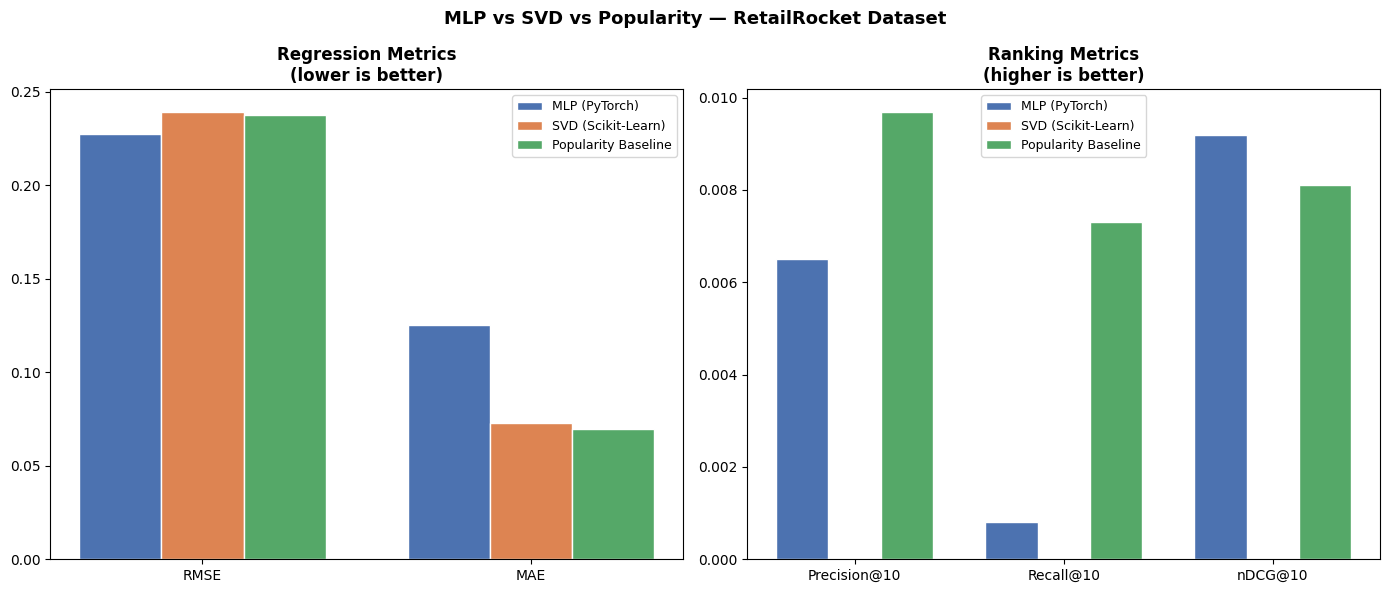

In [8]:
results_df = pd.DataFrame(results).T
print("\n" + "=" * 65)
print("MODEL COMPARISON — TEST SET")
print("=" * 65)
print(results_df.to_string())
print("=" * 65)
print("\nInterpretation:")
print("  RMSE/MAE    : lower is better")
print(f"  Precision@{K}: higher is better — fraction of relevant top-{K} items")
print(f"  Recall@{K}   : higher is better — coverage of relevant items")
print(f"  nDCG@{K}     : higher is better — considers the position of the hit")

# Comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
models = list(results.keys())
colors = ["#4C72B0", "#DD8452", "#55A868"]

# Error metrics (lower = better)
error_metrics = ["RMSE", "MAE"]
x = np.arange(len(error_metrics))
width = 0.25
for i, (name, color) in enumerate(zip(models, colors)):
    vals = [results[name][m] for m in error_metrics]
    axes[0].bar(x + i * width, vals, width, label=name, color=color, edgecolor="white")
axes[0].set_title("Regression Metrics\n(lower is better)", fontweight="bold")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(error_metrics)
axes[0].legend(fontsize=9)

# Ranking metrics (higher = better)
ranking_metrics = [f"Precision@{K}", f"Recall@{K}", f"nDCG@{K}"]
x = np.arange(len(ranking_metrics))
for i, (name, color) in enumerate(zip(models, colors)):
    vals = [results[name][m] for m in ranking_metrics]
    axes[1].bar(x + i * width, vals, width, label=name, color=color, edgecolor="white")
axes[1].set_title("Ranking Metrics\n(higher is better)", fontweight="bold")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(ranking_metrics)
axes[1].legend(fontsize=9)

plt.suptitle("MLP vs SVD vs Popularity — RetailRocket Dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/fig_08_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
EXAMPLE_USER = 0

print(f"Recommendations for user {EXAMPLE_USER}")
print("=" * 50)

# User history
history = train[train["user_idx"] == EXAMPLE_USER].sort_values("rating", ascending=False)
print("\nInteraction history (training set):")
print(f"{'Item':<10} {'Original Score':<20} {'Norm. Rating'}")
print("-" * 45)
for _, row in history.head(5).iterrows():
    event = {0.0: "view", 0.5: "addtocart", 1.0: "transaction"}.get(row["rating"], f"{row['rating']:.2f}")
    print(f"  {int(row['item_idx']):<8} {event:<20} {row['rating']:.2f}")

# Recommendations from the 3 models
print("\nTop-10 recommendations:")
print(f"{'Position':<10} {'MLP':<12} {'SVD':<12} {'Popularity'}")
print("-" * 48)
mlp_recs = mlp_recommend(EXAMPLE_USER, top_k=10)
svd_recs = svd_recommend(EXAMPLE_USER, top_k=10)
pop_recs = pop_recommend(EXAMPLE_USER, top_k=10)
for pos, (m, s, p) in enumerate(zip(mlp_recs, svd_recs, pop_recs), 1):
    print(f"  {pos:<8} {m:<12} {s:<12} {p}")

Recommendations for user 0

Interaction history (training set):
Item       Original Score       Norm. Rating
---------------------------------------------
  5860     view                 0.00
  9653     view                 0.00
  4901     view                 0.00
  9302     view                 0.00
  6628     view                 0.00

Top-10 recommendations:
Position   MLP          SVD          Popularity
------------------------------------------------
  1        9693         19229        10623
  2        17808        6403         12835
  3        19016        6405         9713
  4        7116         6406         1518
  5        1672         6407         15472
  6        2201         6408         410
  7        17427        6409         9592
  8        9436         6410         15197
  9        18381        6411         19016
  10       13684        6412         10006


In [1]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          CONCLUSION — RETAILROCKET EXPERIMENTS              ║
╚══════════════════════════════════════════════════════════════╝

DECISION: Dataset replaced with MovieLens 100K

TECHNICAL REASON:
  RetailRocket has a structural problem for rating
  prediction models:

  • 96.7% of the events are views
  • normalized view = 0.00 (no real preference signal)
  • Most users have a completely zero-valued history
  • The model cannot distinguish preferences

RESULTS OBTAINED:
  Filter >= 10: 1,502 users · 40,574 interactions
    MLP nDCG@10: 0.0272 vs Popularity: 0.0440

  Filter >= 5: 23,620 users · 255,398 interactions
    MLP nDCG@10: 0.0116 vs Popularity: 0.0081

  In both cases, the MLP does not consistently outperform
  Popularity on ranking metrics.

LESSON LEARNED:
  For implicit feedback with highly imbalanced events
  (96% views), the ideal approach would be to use BPR loss
  (Bayesian Personalized Ranking) instead of MSELoss — which
  treats the problem as direct ranking, not rating prediction.

  RetailRocket would be a better dataset for a pure BPR model.
  To demonstrate an MLP with ratings, MovieLens is more suitable.

NEXT STEP:
  See notebook 03_model_experiments_movielens.ipynb
""")


╔══════════════════════════════════════════════════════════════╗
║          CONCLUSION — RETAILROCKET EXPERIMENTS              ║
╚══════════════════════════════════════════════════════════════╝

DECISION: Dataset replaced with MovieLens 100K

TECHNICAL REASON:
  RetailRocket has a structural problem for rating
  prediction models:

  • 96.7% of the events are views
  • normalized view = 0.00 (no real preference signal)
  • Most users have a completely zero-valued history
  • The model cannot distinguish preferences

RESULTS OBTAINED:
  Filter >= 10: 1,502 users · 40,574 interactions
    MLP nDCG@10: 0.0272 vs Popularity: 0.0440

  Filter >= 5: 23,620 users · 255,398 interactions
    MLP nDCG@10: 0.0116 vs Popularity: 0.0081

  In both cases, the MLP does not consistently outperform
  Popularity on ranking metrics.

LESSON LEARNED:
  For implicit feedback with highly imbalanced events
  (96% views), the ideal approach would be to use BPR loss
  (Bayesian Personalized Ranking) instead o